In [16]:
import polars as pl, pymc as pm, arviz as az, numpy as np, pandas as pd

In [17]:
def inv_logit(x):
    return np.exp(x) / (1 + np.exp(x))


def sim_happiness(N_years=100, seed=1234):
    np.random.seed(seed)


    popn = pd.DataFrame(np.zeros((20 * 65, 3)), columns=["age", "happiness", "married"])
    popn.loc[:, "age"] = np.repeat(np.arange(65), 20)
    popn.loc[:, "happiness"] = np.repeat(np.linspace(-2, 2, 20), 65)
    popn.loc[:, "married"] = np.array(popn.loc[:, "married"].values, dtype="bool")

    for i in range(N_years):
        # age population
        popn.loc[:, "age"] += 1
        # replace old folk with new folk
        ind = popn.age == 65
        popn.loc[ind, "age"] = 0
        popn.loc[ind, "married"] = False
        popn.loc[ind, "happiness"] = np.linspace(-2, 2, 20)

        # do the work
        elligible = (popn.married == 0) & (popn.age >= 18)
        marry = np.random.binomial(1, inv_logit(popn.loc[elligible, "happiness"] - 4)) == 1
        popn.loc[elligible, "married"] = marry

    popn.sort_values("age", inplace=True, ignore_index=True)

    return popn

df = pl.from_pandas(sim_happiness()).with_columns(pl.col("married").cast(pl.Int8))

/var/folders/3g/qw0kh7k15n90fnk3l1jxy2d80000gn/T/ipykernel_46668/1337673154.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  popn.loc[:, "married"] = np.array(popn.loc[:, "married"].values, dtype="bool")


In [26]:
# standaradize the happiness
def standardize_columns(df_: pl.DataFrame, cols: list[str]) -> pl.DataFrame:
    return df_.with_columns((pl.col(*cols) - pl.col(*cols).mean()) / pl.col(*cols).std())

df = standardize_columns(df, ["happiness", "age"])

In [27]:
# model it

with pm.Model() as first_model:
    alpha = pm.Normal("alpha", 0, 1)
    beta = pm.Normal("beta", 0, 2, shape=2)
    sigma = pm.Exponential("sigma", 1)

    mu = alpha + beta[0]*df["age"].to_numpy() + beta[1]*df["married"].to_numpy()
    happiness = pm.Normal("happiness", mu, sigma, observed=df["happiness"].to_numpy())

    prior_distribution = pm.sample_prior_predictive(draws=500)

    posterior_distribution = pm.sample(draws=500)

with pm.Model() as second_model:
    alpha = pm.Normal("alpha", 0, 1)
    beta = pm.Normal("beta", 0, 2)
    sigma = pm.Exponential("sigma", 1)

    mu = alpha + beta*df["age"].to_numpy()
    happiness = pm.Normal("happiness", mu, sigma, observed=df["happiness"].to_numpy())

    prior_distribution_no_marriage = pm.sample_prior_predictive(draws=500)

    posterior_distribution_no_marriage = pm.sample(draws=500)

Sampling: [alpha, beta, happiness, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.
Sampling: [alpha, beta, happiness, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 0 seconds.


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

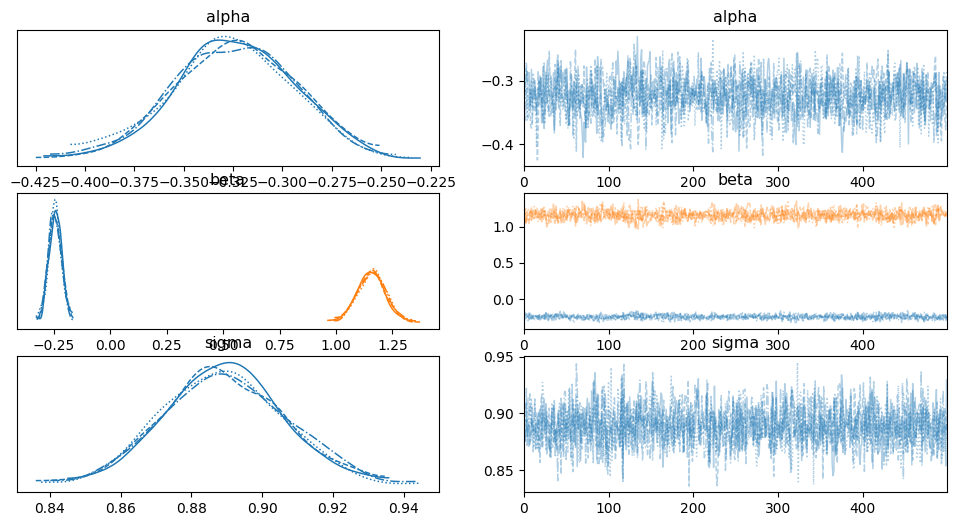

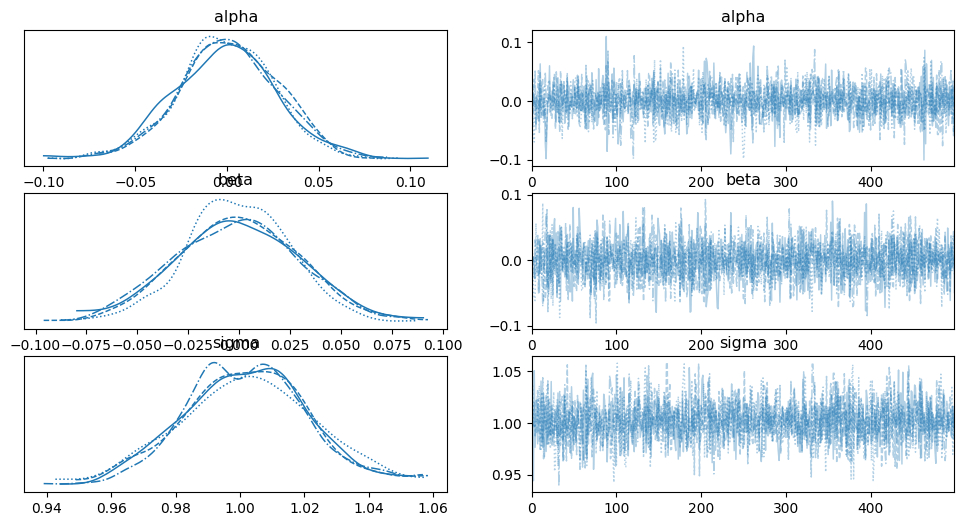

In [28]:
az.plot_trace(posterior_distribution)
az.plot_trace(posterior_distribution_no_marriage)

## Model comparison

In [29]:
with first_model:
    pm.compute_log_likelihood(posterior_distribution)

with second_model:
    pm.compute_log_likelihood(posterior_distribution_no_marriage)

Output()

Output()

In [30]:
comparison_data = az.compare({
    "marrige_included": posterior_distribution,
    "no_marriage": posterior_distribution_no_marriage
}, scale="deviance", ic="waic")
comparison_data

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
marrige_included,0,3385.969445,3.412522,0.0000,1.0,40.099392,0.000000,False,deviance
no_marriage,1,3693.855945,2.491588,307.8865,0.0,32.070708,31.181494,False,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_waic (deviance)', ylabel='ranked models'>

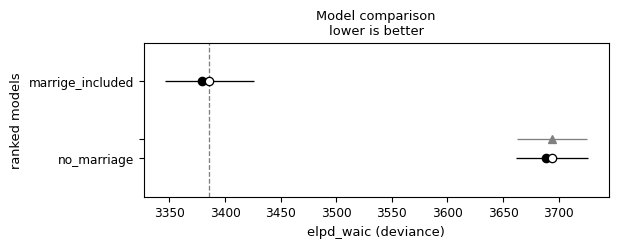

In [31]:
az.plot_compare(comparison_data, insample_dev=True, plot_ic_diff=True)